In [1]:
from doctest import register_optionflag

import numpy as np
import pandas as pd

from MachineLearningNotebook.StudentsGradeExercises import X_train, y_train, regression

np.random.seed(42)
n = 120
uretim_hizi = np.random.uniform(40, 100, n)
sicaklik = np.random.uniform(180, 240, n)
nem = np.random.uniform(30, 60, n)


kalite_puani = (0.6 * uretim_hizi) - (0.4 * sicaklik) + (0.2 * nem) + np.random.normal(50, 5, n)

df = pd.DataFrame({
    'Uretim_Hizi': uretim_hizi,
    'Sicaklik': sicaklik,
    'Nem': nem,
    'Panel_Kalite_Puani': kalite_puani
})
df.to_csv("agt_uretim_verisi.csv", index=False)
print("Veri seti başarıyla oluşturuldu ve 'agt_uretim_verisi.csv' olarak kaydedildi!")

Veri seti başarıyla oluşturuldu ve 'agt_uretim_verisi.csv' olarak kaydedildi!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
df = pd.read_csv("agt_uretim_verisi.csv")

In [4]:
df.head()

,Uretim_Hizi,Sicaklik,Nem,Panel_Kalite_Puani
0,62.472407,228.446409,58.213758,15.677716
1,97.042858,233.765478,58.617857,20.254018
2,83.919637,199.080208,57.445932,42.874052
3,75.919509,186.603115,41.104761,19.370972
4,49.361118,193.676110,30.463698,7.480041


In [6]:
y = df["Panel_Kalite_Puani"]
X = df[["Uretim_Hizi", "Sicaklik", "Nem"]]

#y = df.iloc[:,-1]
#X = df.iloc[:,:-1]

In [7]:
print(X.shape)

(120, 3)


In [8]:
print(y.shape)

(120,)


In [9]:
X_train, X_test ,y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [10]:
print(X_train.shape)

(96, 3)


In [11]:
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
regression = LinearRegression()

In [15]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[10.56,-7.11, 2.58]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.34
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[10.82, 9.53, 8.95]"


In [16]:
regression.coef_

array([10.56244399, -7.1128687 ,  2.58446539])

In [17]:
regression.intercept_

np.float64(16.337851182582178)

In [18]:
y_pred = regression.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)

In [20]:
print("mae:" , mae)

mae: 3.559311292378742


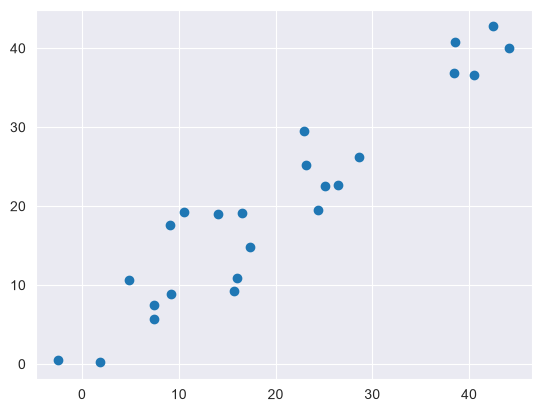

In [21]:
plt.scatter(y_test, y_pred)

<Axes: xlabel='Uretim_Hizi', ylabel='Panel_Kalite_Puani'>

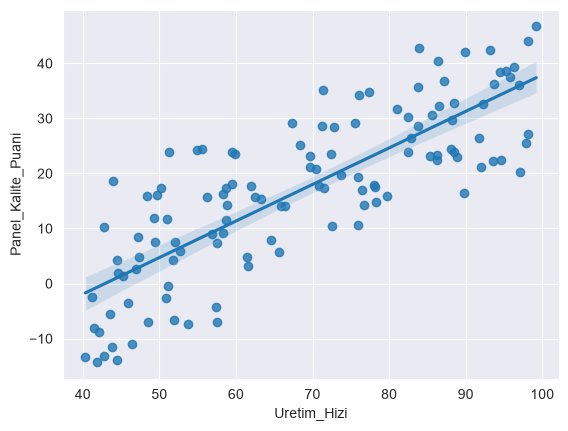

In [22]:
sns.regplot(x = df["Uretim_Hizi"], y =df["Panel_Kalite_Puani"])

<Axes: xlabel='Sicaklik', ylabel='Panel_Kalite_Puani'>

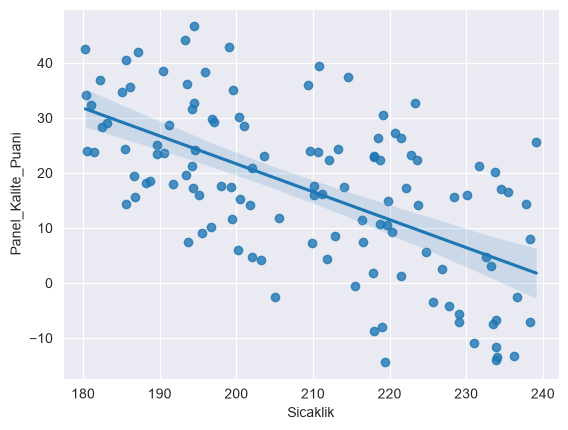

In [26]:
sns.regplot(x = df["Sicaklik"], y =df["Panel_Kalite_Puani"])

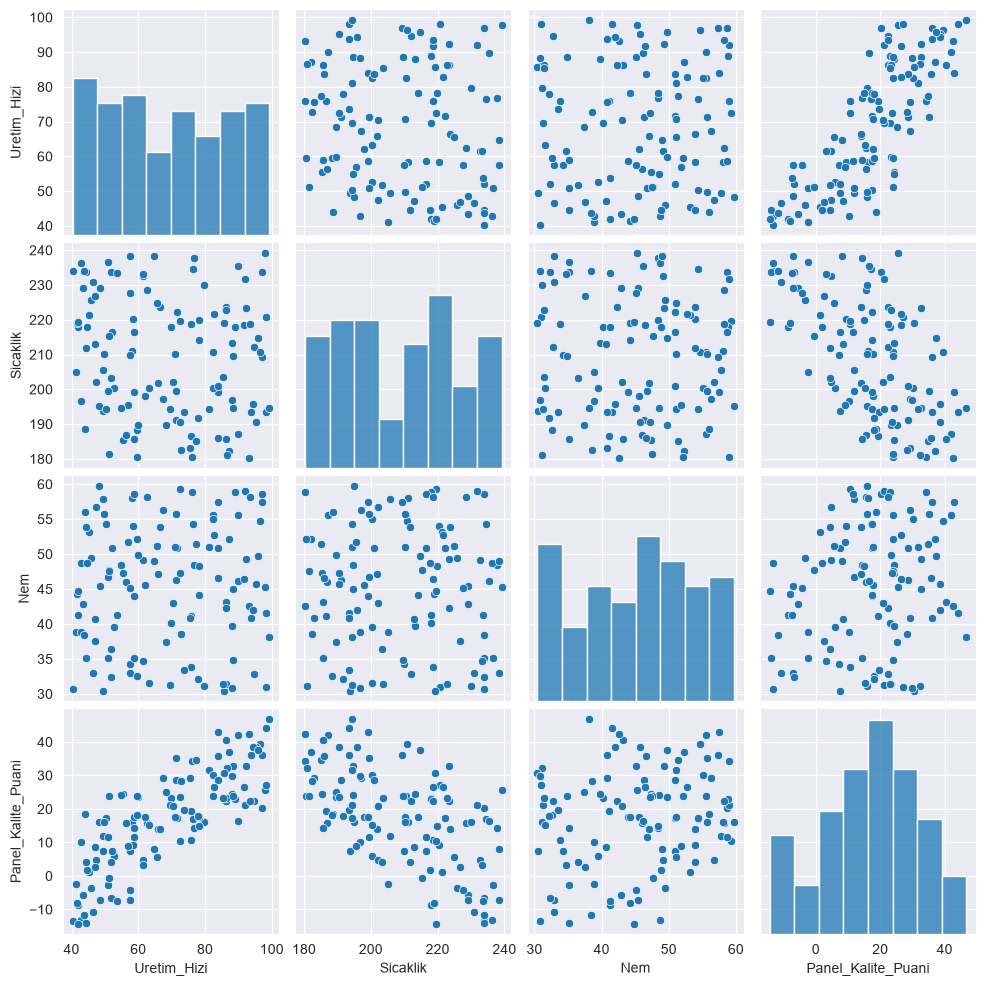

In [24]:
sns.pairplot(df)